# Mortalidad por accidentes de tránsito en Bogotá
## Primera entrega de ETL · copia 2015-2025

Objetivo: describir años, localidades, condiciones de las víctimas y momentos con mayor cantidad de casos registrados. Relación con ODS 3.6 y 11.2.

**Límite de la fuente:** 12.386 filas originales y 18 variables; 6.193 filas analíticas y 6.200 casos. La réplica del nivel Bogotá se excluye para no contar dos veces. El mínimo analítico de 10.000 filas requiere aclaración o ampliación de fuente.

Todas las consultas de este notebook leen la base SQLite. Ejecutar primero `python -m src.etl` desde la raíz del proyecto.

In [1]:
from pathlib import Path
import sys
import json
import pandas as pd
from IPython.display import display, Image

raiz = Path.cwd()
if not (raiz / 'src').is_dir():
    raiz = raiz.parent
if str(raiz) not in sys.path:
    sys.path.insert(0, str(raiz))
from src.analisis import conectar, consultas, perfil, generar
con = conectar(raiz / 'data/processed/accidentes.sqlite')

## 1. Revisar la carga y el tamaño
La auditoría conserva la huella del CSV, los totales y el resultado de comparar los dos niveles geográficos.

In [2]:
display(pd.read_sql_query('SELECT * FROM auditoria', con))
df = pd.read_sql_query('SELECT * FROM vw_mortalidad', con)
print('Filas analíticas y columnas de la vista:', df.shape)
display(df.head())

,clave,valor
0,sha256_csv,"""1ed3cc6639ce43caf31b303d44501015c4a65262e724c..."
1,filas_originales,12386
2,columnas_originales,18
3,suma_bruta_no_utilizar,12400
4,filas_distritales_excluidas_del_hecho,6193
5,replica_geografica_exacta,true
6,filas_analiticas,6193
7,casos_analiticos,6200
8,duplicados_exactos_fuente_excedentes,20
9,duplicados_exactos_detalle_excedentes,0


Filas analíticas y columnas de la vista: (6193, 23)


,fila_fuente,casos,anio,mes,mes_numero,dia,dia_numero,franja_hora,hora_inicio,codigo_localidad,...,ciclo_vital,condicion_victima,pais_nacimiento,pertenencia_grupal,ancestro_racial,pertenencia_etnica,medio_transporte,objeto_colision,tipo_accidente,circunstancia
0,4,1,2015,abril,4.0,jueves,4.0,18:00 a 20:59,18.0,3,...,(29 a 59) Adultez,Pasajero,Colombia,Ninguno,Mestizo,Sin información,Automóvil,Camión - furgón,Choque con otro vehículo,Otras circunstancias no especificadas
1,6,1,2015,agosto,8.0,domingo,7.0,00:00 a 02:59,0.0,8,...,(18 a 28) Juventud,Pasajero,Colombia,Otro,Mestizo,Sin información,Automóvil,Objeto fijo,Choque con objeto fijo o en movimiento,Exceso de velocidad
2,7,1,2015,febrero,2.0,miércoles,3.0,00:00 a 02:59,0.0,10,...,(29 a 59) Adultez,Conductor,Colombia,Otro,Mestizo,Sin información,Automóvil,Objeto fijo,Choque con objeto fijo o en movimiento,Malas condiciones de la vía
3,8,1,2015,octubre,10.0,viernes,5.0,00:00 a 02:59,0.0,6,...,(29 a 59) Adultez,Pasajero,Colombia,Ninguno,Mestizo,Sin información,Automóvil,Objeto fijo,Choque con objeto fijo o en movimiento,Otras circunstancias no especificadas
4,9,1,2015,abril,4.0,sábado,6.0,00:00 a 02:59,0.0,8,...,(18 a 28) Juventud,Conductor,Colombia,Otro,Mestizo,Sin información,Automóvil,Objeto fijo,Choque con objeto fijo o en movimiento,Embriaguez (Alcohólica y no alcohólica)


Las 23 columnas de la vista incluyen las 18 variables de origen y campos de apoyo derivados. No son 23 variables originales. La unidad de análisis es el registro agregado de la fuente local, no un accidente individual identificado.

## 2. Confirmar el doble nivel antes de analizar

In [3]:
display(pd.read_sql_query("""SELECT nivel_geografico, COUNT(*) AS registros, SUM(casos) AS casos
FROM stg_mortalidad GROUP BY nivel_geografico""", con))
display(pd.read_sql_query("""SELECT COUNT(*) AS registros, SUM(casos) AS casos,
MIN(casos) AS minimo, MAX(casos) AS maximo FROM hecho_mortalidad""", con))

,nivel_geografico,registros,casos
0,distrital,6193,6200
1,local,6193,6200


,registros,casos,minimo,maximo
0,6193,6200,1,2


Los dos bloques suman 6.200 casos cada uno. Además de los totales, el ETL compara todas las combinaciones de los otros 16 campos y sus frecuencias. Se conservan los casos locales sin ubicación (código 21). Hay 20 repeticiones exactas excedentes en la fuente, pero ninguna en el detalle local: una eliminación genérica de duplicados no resuelve el problema de niveles.

## 3. Tipos, faltantes y distribución
No tener NULL no significa que todas las variables estén informadas. Se separa “Sin información” de “No aplica”.

In [4]:
display(df.dtypes.astype(str).to_frame('tipo'))
display(perfil(con))
display(df[['casos']].describe())
display(df.select_dtypes(include='object').describe().T)

,tipo
fila_fuente,int64
casos,int64
anio,int64
mes,object
mes_numero,float64
dia,object
dia_numero,float64
franja_hora,object
hora_inicio,float64
codigo_localidad,int64


,campo,registros,categorias,nulos,sin_informacion,pct_sin_informacion,no_aplica
0,codigo_localidad,6193,21,0,0,0.00,0
1,anio,6193,11,0,0,0.00,0
2,casos,6193,2,0,0,0.00,0
3,sexo,6193,2,0,0,0.00,0
4,mes,6193,13,0,1,0.02,0
5,dia,6193,8,0,1,0.02,0
6,franja_hora,6193,9,0,2047,33.05,0
7,pertenencia_grupal,6193,35,0,387,6.25,0
8,pais_nacimiento,6193,11,0,32,0.52,0
9,tipo_accidente,6193,11,0,139,2.24,0


,casos
count,6193.000000
mean,1.001130
std,0.033604
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,2.000000


,count,unique,top,freq
mes,6193,13,octubre,589
dia,6193,8,sábado,1049
franja_hora,6193,9,Sin información,2047
localidad,6193,21,Kennedy,812
sexo,6193,2,Hombre,4867
ciclo_vital,6193,7,(29 a 59) Adultez,2571
condicion_victima,6193,4,Conductor,2942
pais_nacimiento,6193,11,Colombia,5990
pertenencia_grupal,6193,35,Ninguno,4704
ancestro_racial,6193,7,Mestizo,4799


No se eliminan los registros con dos casos: siete filas representan dos muertes cada una. No se calculan promedios de códigos de localidad ni correlaciones de códigos categóricos. Tampoco se inventa edad a partir del ciclo vital. El valor “Fetos” necesita revisión con el publicador.

## 4. Resultados y gráficos desde consultas SQL

In [5]:
tablas, resumen = generar(raiz / 'data/processed/accidentes.sqlite', raiz / 'reports')
print('Casos analizados:', resumen['casos'])
print('Registros analizados:', resumen['registros'])

Casos analizados: 6200
Registros analizados: 6193


### 4.1. Evolución anual

In [6]:
print(consultas()['anual'])
display(tablas['anual'])

SELECT anio, COUNT(*) AS registros, SUM(casos) AS casos
FROM vw_mortalidad GROUP BY anio ORDER BY anio;


,anio,registros,casos,variacion_pct
0,2015,553,556,NaN
1,2016,591,591,6.29
2,2017,553,553,-6.43
3,2018,527,527,-4.70
4,2019,523,523,-0.76
5,2020,404,406,-22.37
6,2021,507,508,25.12
7,2022,630,630,24.02
8,2023,628,629,-0.16
9,2024,665,665,5.72


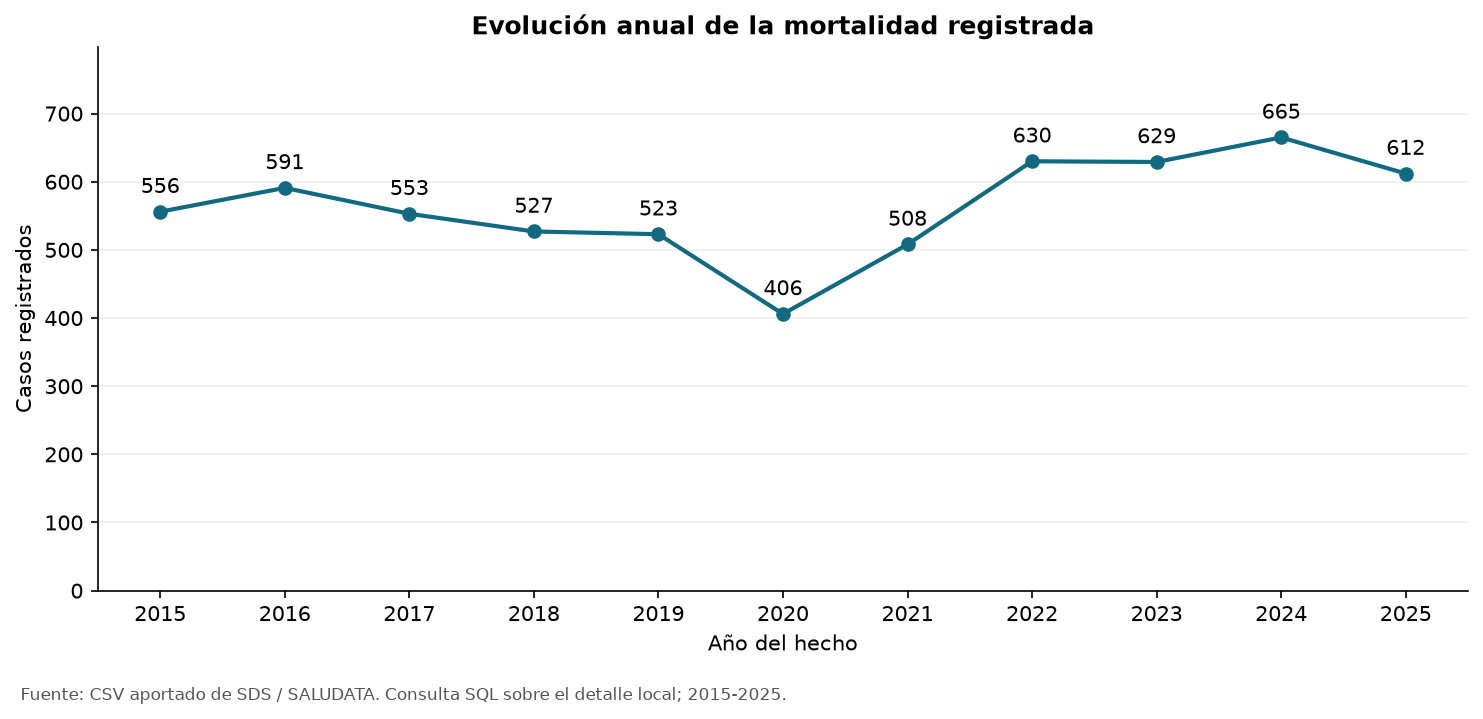

In [7]:
display(Image(filename=str(raiz / 'reports/figures/01_evolucion_anual.png')))

El mínimo observado es 2020 (406 casos) y el máximo es 2024 (665). En 2025 hay 612, un descenso de 7,97% respecto a 2024. La serie no permite atribuir estos cambios a una política o a la pandemia; sería necesario investigar otras fuentes.

### 4.2. Distribución territorial

In [8]:
print(consultas()['localidades'])
display(tablas['localidades'])

SELECT codigo_localidad, localidad, SUM(casos) AS casos
FROM vw_mortalidad WHERE ubicacion_conocida = 1
GROUP BY codigo_localidad, localidad ORDER BY casos DESC;


,codigo_localidad,localidad,casos
0,8,Kennedy,813
1,10,Engativá,564
2,11,Suba,459
3,19,Ciudad Bolívar,430
4,9,Fontibón,399
5,7,Bosa,391
6,16,Puente Aranda,384
7,1,Usaquén,365
8,6,Tunjuelito,265
9,5,Usme,264


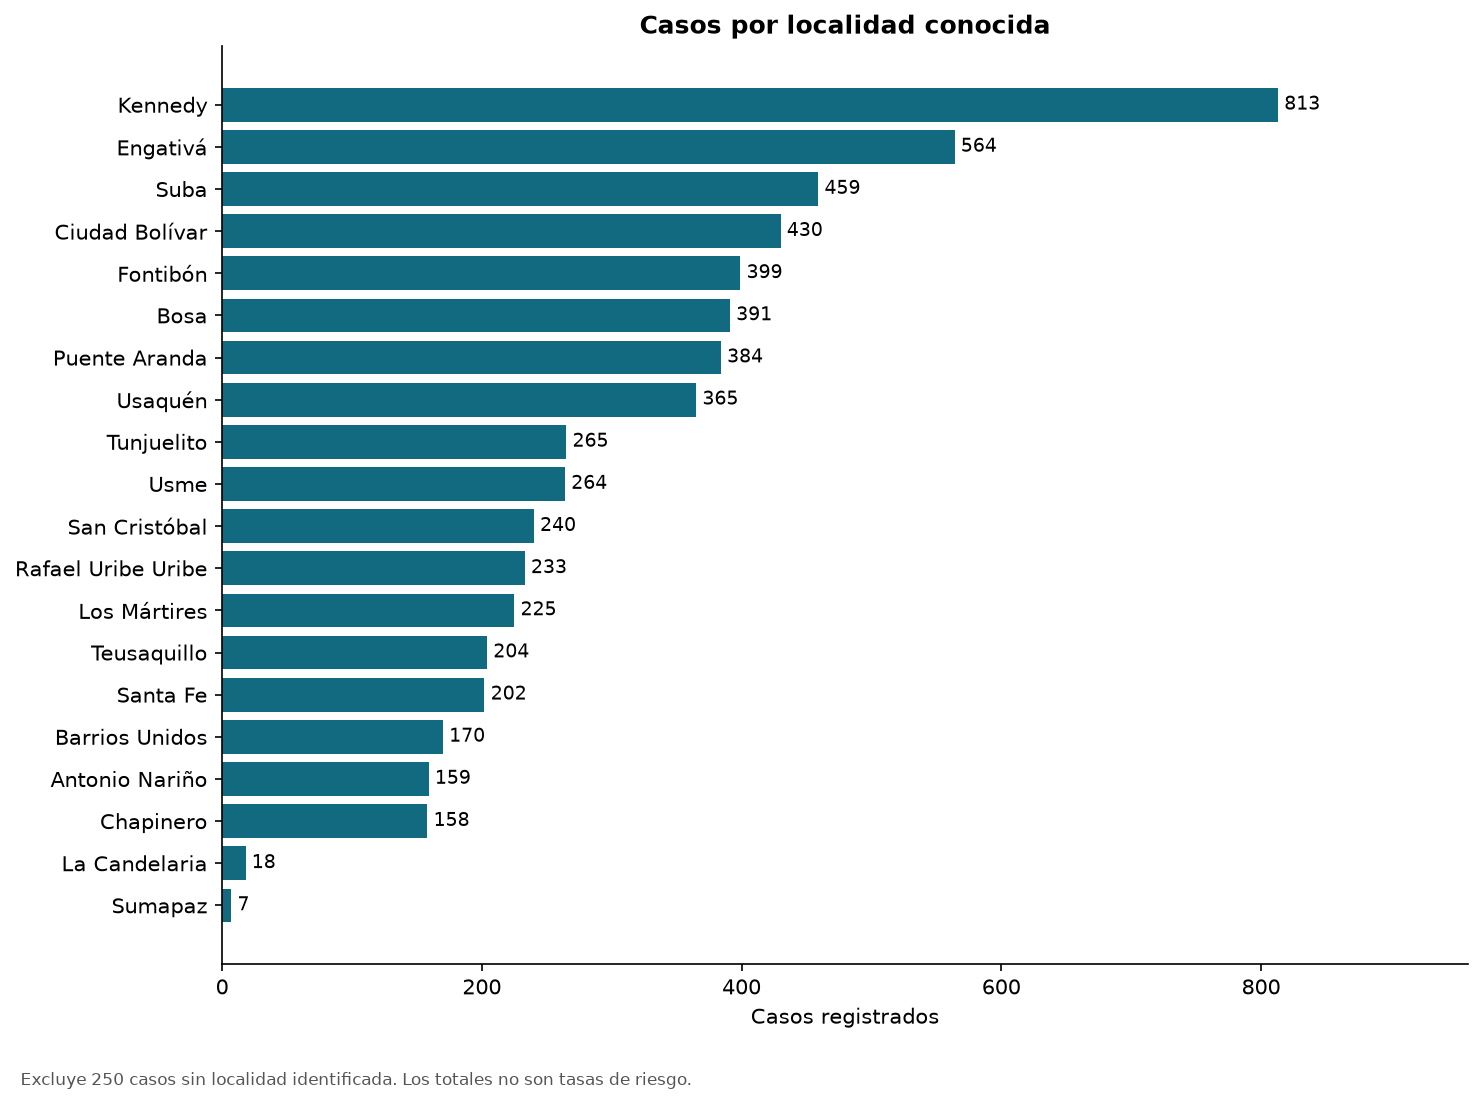

In [9]:
display(Image(filename=str(raiz / 'reports/figures/02_localidades.png')))

Kennedy reúne 813 casos, seguida de Engativá (564) y Suba (459). Son conteos, no probabilidades individuales ni tasas por población. Se excluyen del ranking 250 casos sin localidad conocida, que sí permanecen en el total de la ciudad.

### 4.3. Condición de la víctima

In [10]:
print(consultas()['victimas'])
display(tablas['victimas'])

SELECT condicion_victima, SUM(casos) AS casos
FROM vw_mortalidad GROUP BY condicion_victima ORDER BY casos DESC;


,condicion_victima,casos
0,Conductor,2945
1,Peatón,2655
2,Pasajero,556
3,Sin información,44


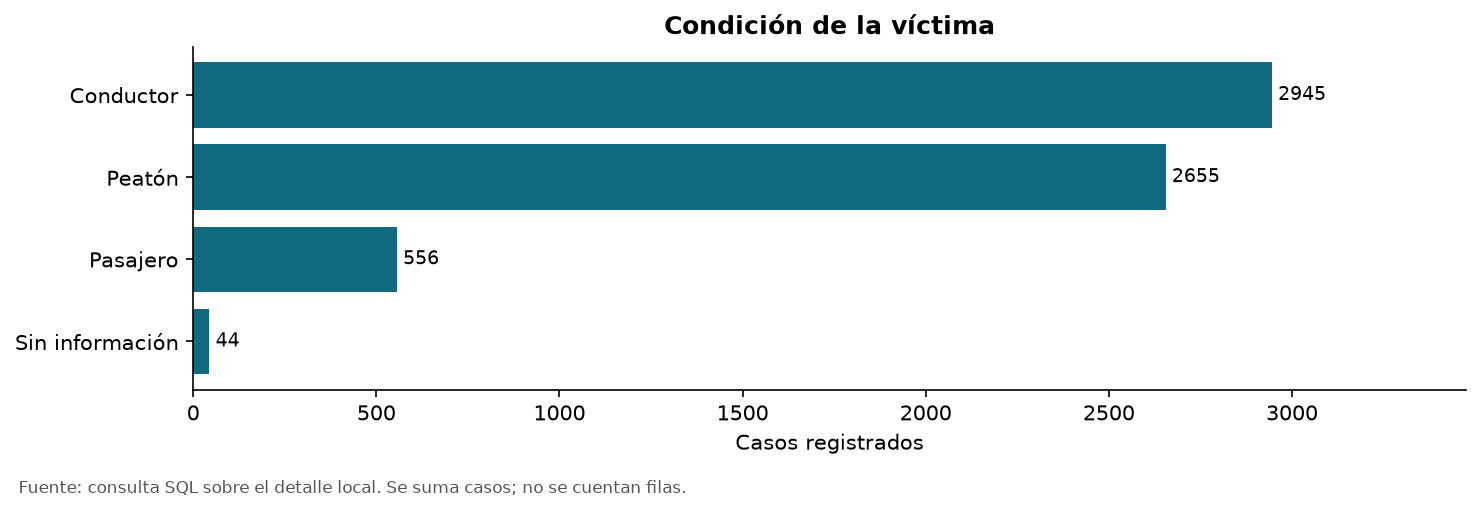

In [11]:
display(Image(filename=str(raiz / 'reports/figures/03_victimas.png')))

Conductores: 2.945 casos; peatones: 2.655; pasajeros: 556; sin información: 44. Los peatones representan 42,82% del total. El dato permite formular preguntas sobre protección peatonal, sin probar el efecto de intervenciones.

### 4.4. Medio de transporte

In [12]:
print(consultas()['transporte'])
display(tablas['transporte'])

SELECT medio_transporte, SUM(casos) AS casos
FROM vw_mortalidad GROUP BY medio_transporte ORDER BY casos DESC;


,medio_transporte,casos
0,No aplica,2406
1,Motocicleta,2319
2,Bicicleta,784
3,Peatón,249
4,Automóvil,164
5,Sin información,58
6,Bus,56
7,Camioneta,47
8,Camión,20
9,Buseta,14


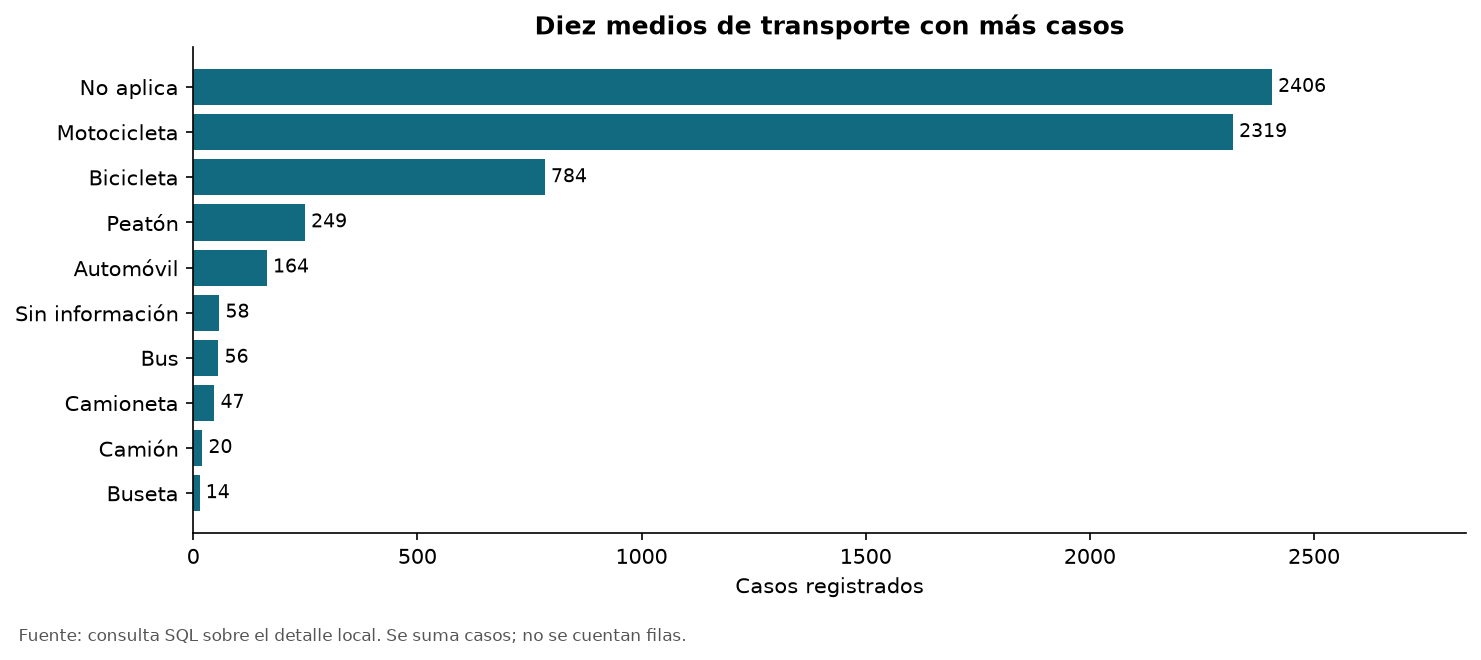

In [13]:
display(Image(filename=str(raiz / 'reports/figures/04_transporte.png')))

Motocicleta suma 2.319 casos. No aplica suma 2.406 y no se borra ni se presenta como un vehículo. La variable describe el medio de la víctima, no necesariamente el vehículo que causó el hecho. Peatón también aparece como categoría del medio: se conserva esa diferencia de codificación.

### 4.5. Ciclo vital

In [14]:
print(consultas()['ciclo_vital'])
display(tablas['ciclo_vital'])

SELECT ciclo_vital, SUM(casos) AS casos
FROM vw_mortalidad GROUP BY ciclo_vital ORDER BY casos DESC;


,ciclo_vital,casos
0,(29 a 59) Adultez,2574
1,(18 a 28) Juventud,1848
2,(Más de 60) Adulto Mayor,1572
3,(12 a 17) Adolescencia,127
4,(06 a 11) Infancia,40
5,(00 a 05) Primera Infancia,38
6,Fetos,1


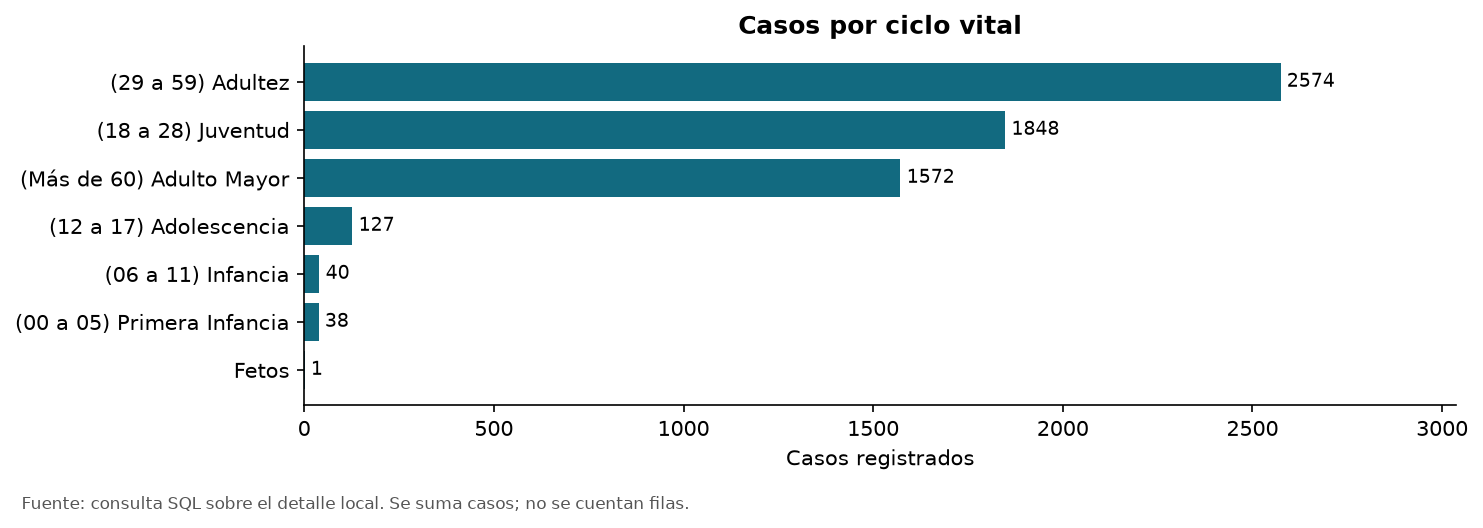

In [15]:
display(Image(filename=str(raiz / 'reports/figures/05_ciclo_vital.png')))

Adultez suma 2.574 casos, juventud 1.848 y adulto mayor 1.572. Los grupos tienen amplitudes distintas: no se compara su riesgo sin población de referencia. La etiqueta original de adulto mayor se conserva y no se usa para inferir edades exactas.

### 4.6. Sexo registrado

In [16]:
print(consultas()['sexo'])
display(tablas['sexo'])

SELECT sexo, SUM(casos) AS casos
FROM vw_mortalidad GROUP BY sexo ORDER BY casos DESC;


,sexo,casos
0,Hombre,4872
1,Mujer,1328


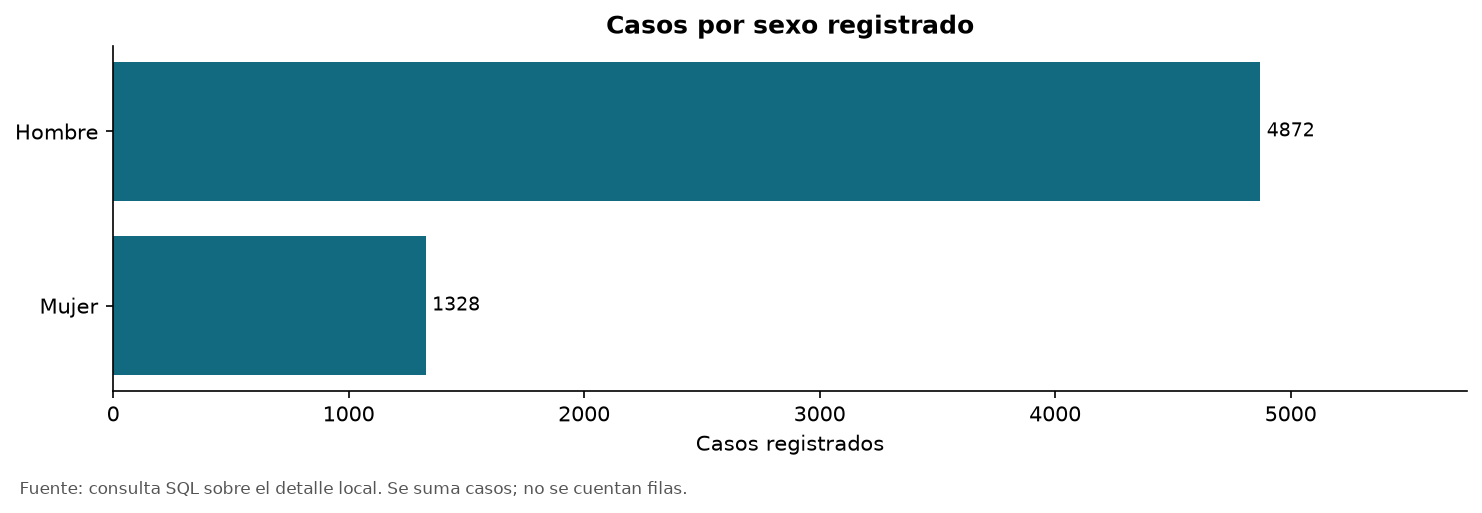

In [17]:
display(Image(filename=str(raiz / 'reports/figures/06_sexo.png')))

Se registran 4.872 casos de hombres (78,58%) y 1.328 de mujeres (21,42%). La distribución no controla diferencias de exposición vial y no demuestra una causa.

### 4.7. Día y hora

In [18]:
print(consultas()['dia_hora'])
display(tablas['dia_hora'])

SELECT dia, dia_numero, franja_hora, hora_inicio, SUM(casos) AS casos
FROM vw_mortalidad WHERE dia_numero IS NOT NULL AND hora_inicio IS NOT NULL
GROUP BY dia, dia_numero, franja_hora, hora_inicio ORDER BY dia_numero, hora_inicio;


,dia,dia_numero,franja_hora,hora_inicio,casos
0,lunes,1,00:00 a 02:59,0,36
1,lunes,1,03:00 a 05:59,3,64
2,lunes,1,06:00 a 08:59,6,76
3,lunes,1,09:00 a 11:59,9,71
4,lunes,1,12:00 a 14:59,12,70
5,lunes,1,15:00 a 17:59,15,94
6,lunes,1,18:00 a 20:59,18,89
7,lunes,1,21:00 a 23:59,21,57
8,martes,2,00:00 a 02:59,0,23
9,martes,2,03:00 a 05:59,3,39


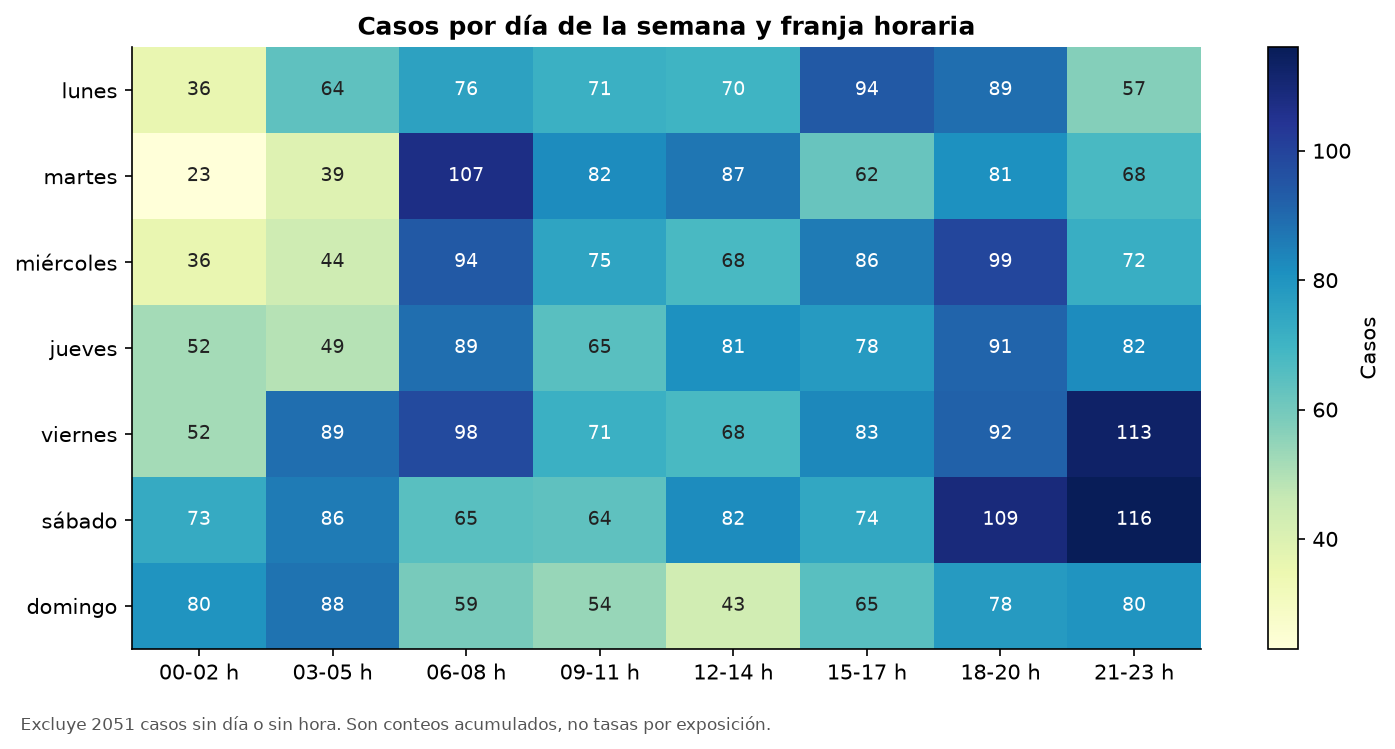

In [19]:
display(Image(filename=str(raiz / 'reports/figures/07_dia_hora.png')))

El mapa usa 4.149 casos con día y hora conocidos; excluye 2.051 (33,08%). La ausencia puede sesgar el patrón. Los valores se acumulan por día de semana y franja de tres horas durante todos los años.

### 4.8. Calidad por variable

In [20]:
display(tablas['calidad_campos'])

,campo,registros,categorias,nulos,sin_informacion,pct_sin_informacion,no_aplica
0,codigo_localidad,6193,21,0,0,0.00,0
1,anio,6193,11,0,0,0.00,0
2,casos,6193,2,0,0,0.00,0
3,sexo,6193,2,0,0,0.00,0
4,mes,6193,13,0,1,0.02,0
5,dia,6193,8,0,1,0.02,0
6,franja_hora,6193,9,0,2047,33.05,0
7,pertenencia_grupal,6193,35,0,387,6.25,0
8,pais_nacimiento,6193,11,0,32,0.52,0
9,tipo_accidente,6193,11,0,139,2.24,0


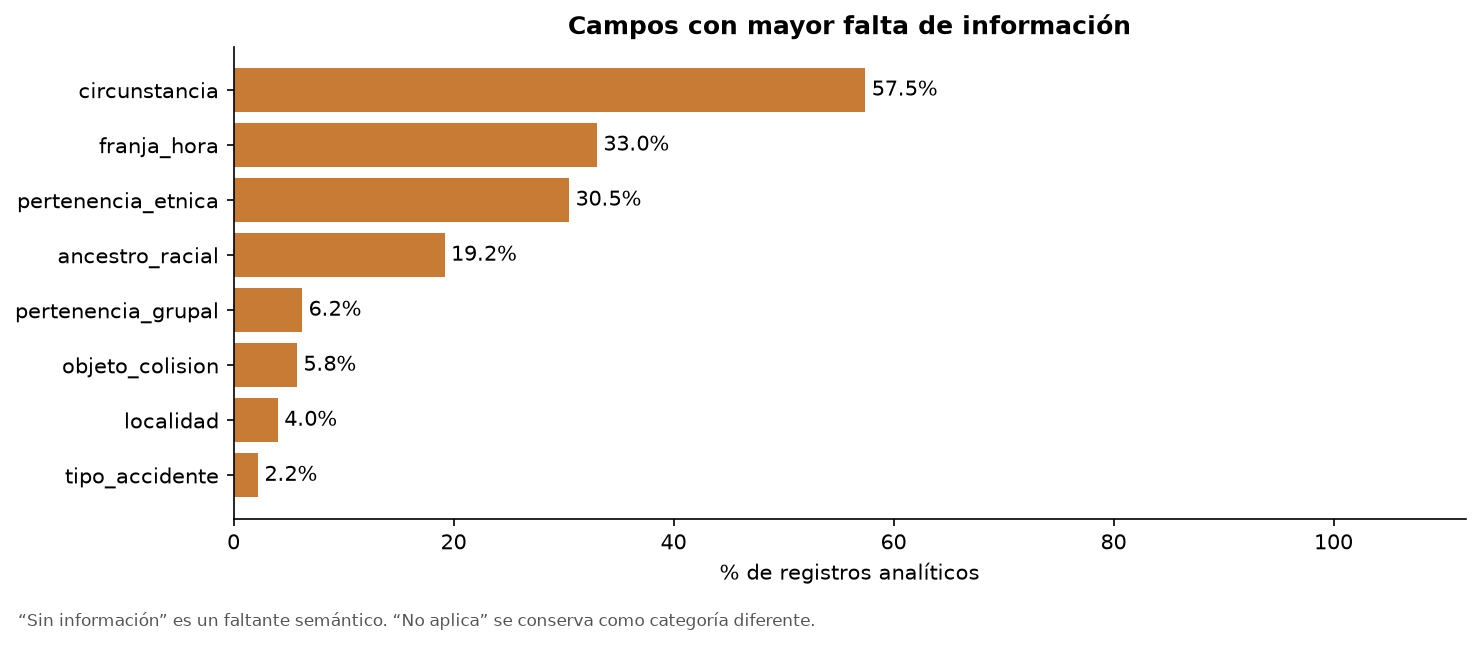

In [21]:
display(Image(filename=str(raiz / 'reports/figures/08_calidad.png')))

El faltante de circunstancia afecta 3.563 casos (57,47%). No se puede explicar la mayoría de muertes a partir de las circunstancias informadas. Esta figura calcula porcentajes de registros, mientras calidad_anual pondera por casos.

### 4.9. Calidad en el tiempo

In [22]:
print(consultas()['calidad_anual'])
display(tablas['calidad_anual'])

SELECT anio, SUM(casos) AS casos,
 ROUND(100.0 * SUM(CASE WHEN circunstancia = 'Sin información' THEN casos ELSE 0 END) / SUM(casos), 2) AS pct_sin_circunstancia,
 ROUND(100.0 * SUM(CASE WHEN hora_inicio IS NULL THEN casos ELSE 0 END) / SUM(casos), 2) AS pct_sin_hora,
 ROUND(100.0 * SUM(CASE WHEN ubicacion_conocida = 0 THEN casos ELSE 0 END) / SUM(casos), 2) AS pct_sin_localidad
FROM vw_mortalidad GROUP BY anio ORDER BY anio;


,anio,casos,pct_sin_circunstancia,pct_sin_hora,pct_sin_localidad
0,2015,556,33.63,13.85,1.80
1,2016,591,49.58,24.70,1.02
2,2017,553,42.86,24.95,0.72
3,2018,527,51.42,18.60,2.09
4,2019,523,51.43,31.93,2.68
5,2020,406,54.43,39.41,3.45
6,2021,508,67.32,42.72,3.35
7,2022,630,70.63,38.10,7.78
8,2023,629,73.13,49.13,8.43
9,2024,665,67.22,42.86,7.67


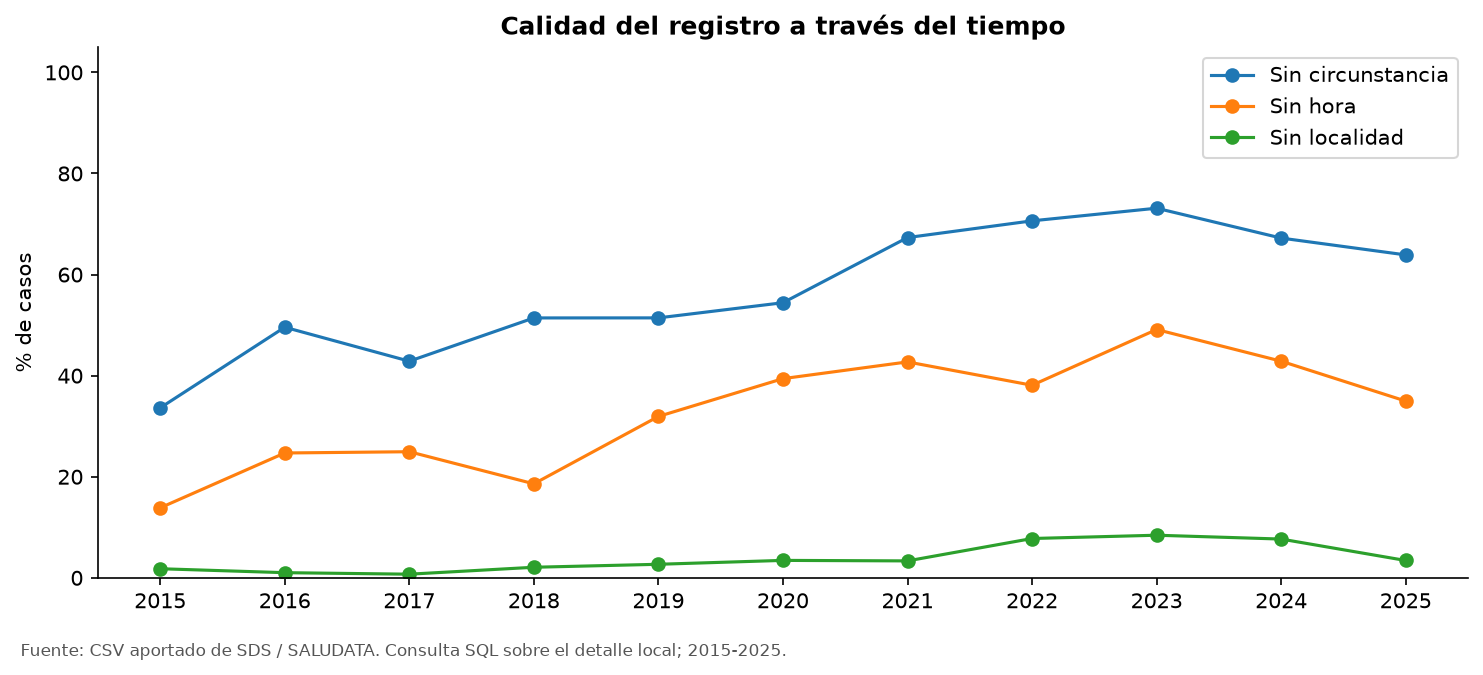

In [23]:
display(Image(filename=str(raiz / 'reports/figures/09_calidad_anual.png')))

La completitud cambia entre años; una diferencia de frecuencia puede reflejar cambios en el registro además de cambios en la mortalidad. Se revisa por separado la circunstancia, la hora y la localidad.

### 4.10. Distribución mensual

In [24]:
print(consultas()['meses'])
display(tablas['meses'])

SELECT mes, mes_numero, SUM(casos) AS casos
FROM vw_mortalidad WHERE mes_numero IS NOT NULL
GROUP BY mes, mes_numero ORDER BY mes_numero;


,mes,mes_numero,casos
0,enero,1,439
1,febrero,2,487
2,marzo,3,503
3,abril,4,484
4,mayo,5,520
5,junio,6,542
6,julio,7,523
7,agosto,8,532
8,septiembre,9,523
9,octubre,10,590


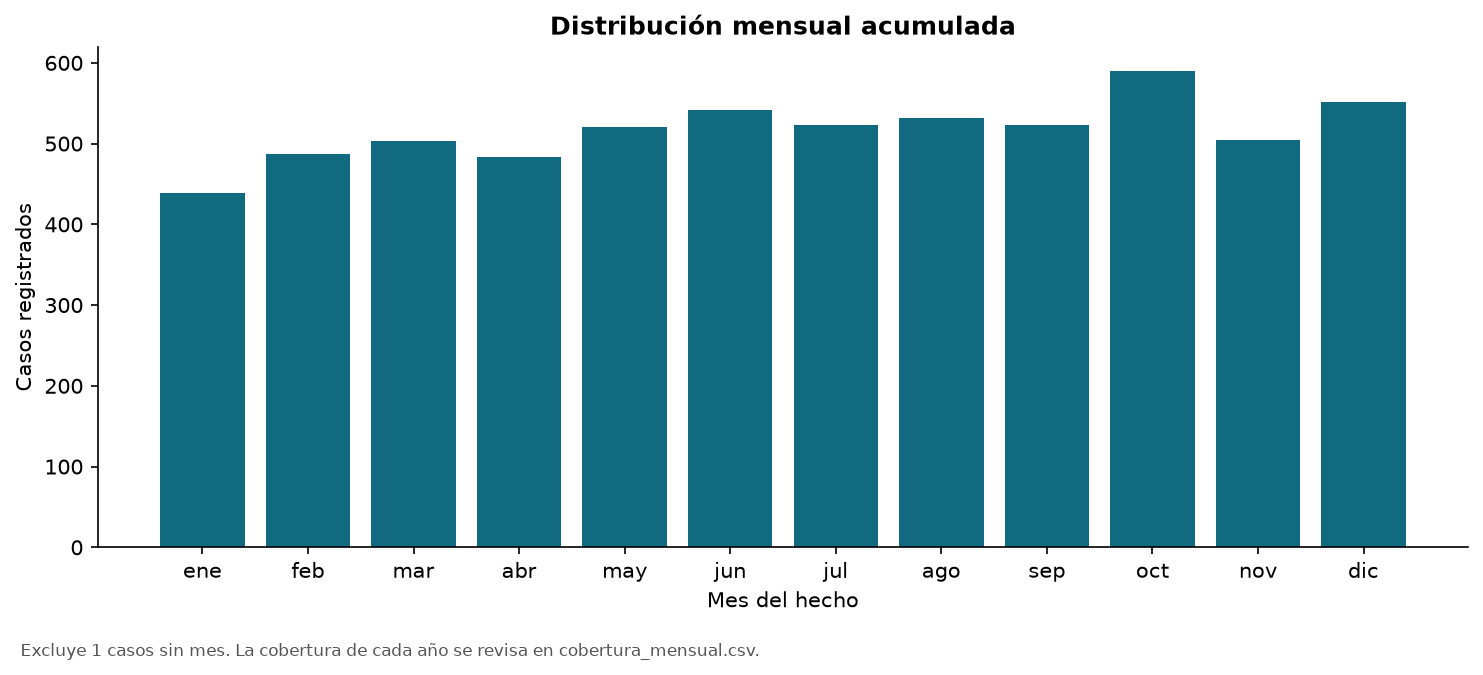

In [25]:
display(Image(filename=str(raiz / 'reports/figures/10_meses.png')))

Se observan datos en los doce meses de todos los años. Falta el mes de un caso. Esto no certifica que la fuente esté cerrada o que la cobertura sea completa; la distribución acumulada tampoco ajusta por la duración de cada mes.

## 5. Comprobar cobertura y cambios de categorías

In [26]:
display(tablas['cobertura_mensual'].pivot(index='anio', columns='mes_numero', values='casos'))
display(tablas['tipos_por_anio'].pivot(index='anio', columns='tipo_accidente', values='casos').fillna(0).astype(int))
display(tablas['sexo_ciclo'])

mes_numero,NaN,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0
anio,,,,,,,,,,,,,
2015,NaN,33.0,30.0,34.0,53.0,58.0,38.0,47.0,41.0,55.0,60.0,48.0,59.0
2016,1.0,48.0,39.0,53.0,46.0,54.0,60.0,46.0,57.0,48.0,52.0,41.0,46.0
2017,NaN,37.0,55.0,39.0,41.0,50.0,49.0,46.0,50.0,45.0,44.0,41.0,56.0
2018,NaN,34.0,44.0,48.0,48.0,45.0,54.0,55.0,38.0,39.0,42.0,42.0,38.0
2019,NaN,26.0,40.0,49.0,40.0,50.0,39.0,56.0,39.0,46.0,61.0,33.0,44.0
2020,NaN,29.0,41.0,26.0,24.0,23.0,27.0,27.0,39.0,42.0,47.0,40.0,41.0
2021,NaN,33.0,38.0,39.0,32.0,33.0,50.0,50.0,50.0,46.0,41.0,42.0,54.0
2022,NaN,38.0,44.0,56.0,52.0,50.0,50.0,58.0,56.0,48.0,63.0,58.0,57.0
2023,NaN,53.0,55.0,47.0,46.0,56.0,65.0,44.0,55.0,48.0,56.0,56.0,48.0


tipo_accidente,Atropello,Caída de aeronave,Caída del ocupante,Caída del vehículo a un precipicio,Choque,Choque con objeto fijo o en movimiento,Choque con otro vehículo,Hundimiento,Incendio,Sin información,Volcamiento
anio,,,,,,,,,,,
2015,273,10,15,1,0,37,182,0,0,19,19
2016,285,0,8,0,274,0,0,0,0,3,21
2017,275,0,7,0,221,0,0,0,0,10,40
2018,243,0,8,2,218,0,0,0,0,25,31
2019,248,0,14,1,218,0,0,0,0,13,29
2020,145,4,9,0,187,0,0,0,0,22,39
2021,189,0,3,3,258,0,0,0,0,19,36
2022,246,0,7,1,322,0,0,0,0,11,43
2023,249,0,9,5,313,0,0,0,0,10,43


,sexo,ciclo_vital,casos
0,Hombre,(00 a 05) Primera Infancia,26
1,Mujer,(00 a 05) Primera Infancia,12
2,Hombre,(06 a 11) Infancia,28
3,Mujer,(06 a 11) Infancia,12
4,Hombre,(12 a 17) Adolescencia,100
5,Mujer,(12 a 17) Adolescencia,27
6,Hombre,(18 a 28) Juventud,1483
7,Mujer,(18 a 28) Juventud,365
8,Hombre,(29 a 59) Adultez,2087
9,Mujer,(29 a 59) Adultez,487


Se conservan categorías como Choque, Choque con otro vehículo y Choque con objeto fijo o en movimiento. Unificarlas sin respaldo perdería detalle y podría distorsionar la comparación temporal. Algunos tipos de transporte publicados exceden la circulación vial habitual: la interpretación queda limitada al alcance del conjunto oficial, sin recortar categorías a conveniencia.

## 6. Conclusiones y siguientes pasos

1. La primera decisión de calidad es separar los niveles geográficos para evitar el doble conteo.
2. Los conductores y peatones concentran gran parte de los casos registrados.
3. La comparación por localidades necesita denominadores poblacionales o de exposición para hablar de riesgo.
4. Los faltantes de hora y circunstancia limitan las conclusiones sobre momentos y causas.
5. El mínimo de 10.000 registros analíticos permanece pendiente. Se requiere confirmación del profesor o una ampliación de datos sin solapamiento.

Fuentes: [Datos Abiertos Bogotá](https://datosabiertos.bogota.gov.co/dataset/mortalidad-por-accidentes-de-transito), metadato de SDS/INMLCF y consigna de primera entrega. Los datos usados son la copia aportada; los metadatos del portal se consultaron el 13/09/2026.

In [27]:
con.close()